# SNR / ivar consistency check

Load 1000 spectra from `spectra_shuffled/` via `SpectraDataset`, compute per-spectrum SNR and good-pixel counts.

In [2]:
import sys
sys.path.insert(0, "../py")

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from spectra_loader import SpectraDataset

In [4]:
ds = SpectraDataset(
    "../spectra_shuffled",
    n_spectra=1000,
    zmin=0.75,
    zmax=1.0,
)
print(f"Dataset size: {len(ds)}")

loader = DataLoader(ds, batch_size=256, num_workers=4)

Dataset size: 1000


In [5]:
snr_vals = []
npix_vals = []

for batch in loader:
    flux = batch["flux"].numpy()  # (B, 7781)
    ivar = batch["ivar"].numpy()  # (B, 7781)
    if np.any(ivar < 0):
        print("Warning: Found negative ivar values, which will be ignored in SNR calculation.")
    mask = ivar > 0               # (B, 7781)
    snr = (flux ** 2 * ivar * mask).sum(axis=1)  # (B,)
    npix = mask.sum(axis=1)                       # (B,)
    snr_vals.append(snr)
    npix_vals.append(npix)

snr_vals = np.concatenate(snr_vals)
npix_vals = np.concatenate(npix_vals)
print(f"Processed {len(snr_vals)} spectra")

Processed 1000 spectra


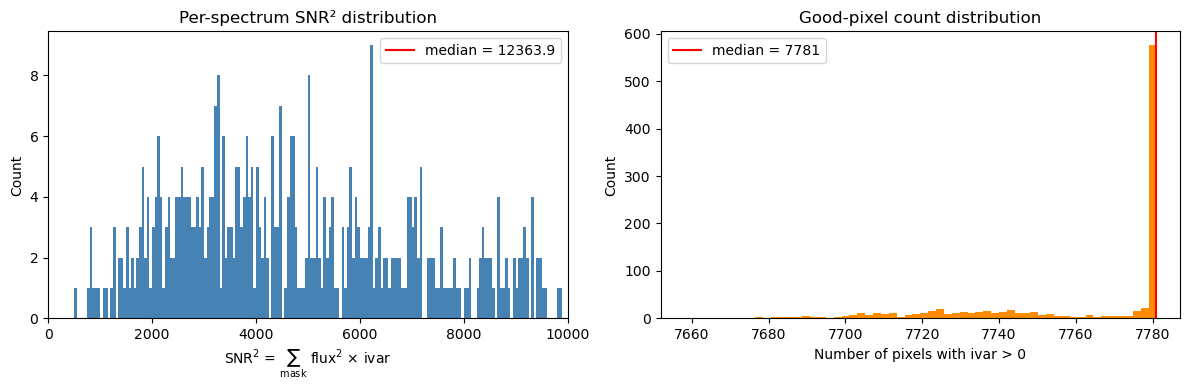

SNR²  — min: 8272.8  median: 20087.4  max: 288102.2
Npix  — min: 7658  median: 7781  max: 7781


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
vals = snr_vals-npix_vals
ax.hist(vals, bins=200, color="steelblue", edgecolor="none", range=(0,10000))
ax.set_xlabel(r"SNR$^2$ = $\sum_{\rm mask}$ flux$^2$ $\times$ ivar")
ax.set_ylabel("Count")
ax.set_title("Per-spectrum SNR² distribution")
ax.axvline(np.median(vals), color="red", lw=1.5, label=f"median = {np.median(vals):.1f}")
ax.set_xlim(0,10000)
ax.legend()

ax = axes[1]
ax.hist(npix_vals, bins=60, color="darkorange", edgecolor="none")
ax.set_xlabel("Number of pixels with ivar > 0")
ax.set_ylabel("Count")
ax.set_title("Good-pixel count distribution")
ax.axvline(np.median(npix_vals), color="red", lw=1.5, label=f"median = {np.median(npix_vals):.0f}")
ax.legend()

plt.tight_layout()
plt.show()

print(f"SNR²  — min: {snr_vals.min():.1f}  median: {np.median(snr_vals):.1f}  max: {snr_vals.max():.1f}")
print(f"Npix  — min: {npix_vals.min()}  median: {np.median(npix_vals):.0f}  max: {npix_vals.max()}")